# Subscription Churn Analysis (OTT / SaaS Style)

This notebook follows a step-by-step flow:
1. Load data
2. Clean and prepare
3. Engineer features
4. Explore churn drivers with visualizations
5. Train churn prediction models
6. Create churn probability and risk segments
7. Summarize recommendations

## Step 1: Import Libraries and Setup
Import all required libraries and set plotting style for clear visuals.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## Step 2: Load Dataset
Load the raw Telco churn CSV and inspect shape and sample rows.

In [3]:
data_path = Path("Telco_Customer_Churn.csv")
df_raw = pd.read_csv(data_path)
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Data Cleaning and PRD Field Mapping
Clean nulls, convert charge fields, and map dataset columns to PRD-style columns.

Because this Telco dataset does not directly contain OTT telemetry fields (`usage_frequency`, `last_login_days`, `customer_support_calls`), we engineer deterministic proxy features from available service and support attributes.

In [4]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()

# Proxy usage frequency from enabled services
df["usage_frequency"] = (
    (df["OnlineSecurity"] == "Yes").astype(int)
    + (df["OnlineBackup"] == "Yes").astype(int)
    + (df["DeviceProtection"] == "Yes").astype(int)
    + (df["TechSupport"] == "Yes").astype(int)
    + (df["StreamingTV"] == "Yes").astype(int)
    + (df["StreamingMovies"] == "Yes").astype(int)
    + (df["PhoneService"] == "Yes").astype(int)
    + (df["MultipleLines"] == "Yes").astype(int)
    + (df["InternetService"] != "No").astype(int)
)

# Proxy last login days
inferred_login_days = (
    30 / (df["usage_frequency"] + 1)
    + np.where(df["Contract"] == "Month-to-month", 5, 0)
    + np.where(df["tenure"] < 6, 7, 0)
)
df["last_login_days"] = np.clip(np.round(inferred_login_days), 1, 60).astype(int)

# Proxy support calls
inferred_support_calls = (
    np.where(df["TechSupport"] == "No", 3, 1)
    + np.where(df["OnlineSecurity"] == "No", 1, 0)
    + np.where(df["OnlineBackup"] == "No", 1, 0)
    + np.where(df["InternetService"] == "Fiber optic", 1, 0)
)
df["customer_support_calls"] = np.clip(inferred_support_calls, 0, 8).astype(int)

df_norm = pd.DataFrame(
    {
        "customer_id": df["customerID"],
        "subscription_plan": df["Contract"],
        "monthly_charges": df["MonthlyCharges"],
        "tenure": df["tenure"],
        "usage_frequency": df["usage_frequency"],
        "last_login_days": df["last_login_days"],
        "customer_support_calls": df["customer_support_calls"],
        "payment_method": df["PaymentMethod"],
        "churn": df["Churn"],
    }
)
df_norm["churn_flag"] = df_norm["churn"].map({"Yes": 1, "No": 0})

print(f"Clean dataset shape: {df_norm.shape}")
df_norm.head()

Clean dataset shape: (7032, 10)


,customer_id,subscription_plan,monthly_charges,tenure,usage_frequency,last_login_days,customer_support_calls,payment_method,churn,churn_flag
0,7590-VHVEG,Month-to-month,29.85,1,2,22,4,Electronic check,No,0
1,5575-GNVDE,One year,56.95,34,4,6,4,Mailed check,No,0
2,3668-QPYBK,Month-to-month,53.85,2,4,18,3,Mailed check,Yes,1
3,7795-CFOCW,One year,42.30,45,4,6,2,Bank transfer (automatic),No,0
4,9237-HQITU,Month-to-month,70.70,2,2,22,6,Electronic check,Yes,1


## Step 4: Feature Engineering
Create engagement score and tenure groups for segmentation and insights.

In [5]:
df_norm["engagement_score"] = df_norm["usage_frequency"] / (df_norm["last_login_days"] + 1)
df_norm["tenure_group"] = pd.cut(
    df_norm["tenure"],
    bins=[-1, 12, 24, 72],
    labels=["New", "Mid", "Loyal"],
)

churn_rate = df_norm["churn_flag"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
df_norm[["engagement_score", "tenure_group"]].head()

Overall Churn Rate: 26.58%


,engagement_score,tenure_group
0,0.086957,New
1,0.571429,Loyal
2,0.210526,New
3,0.571429,Loyal
4,0.086957,New


## Step 5: Churn Rate and Tenure Analysis (Visualization)
Display churn distribution and churn by tenure group as inline charts.

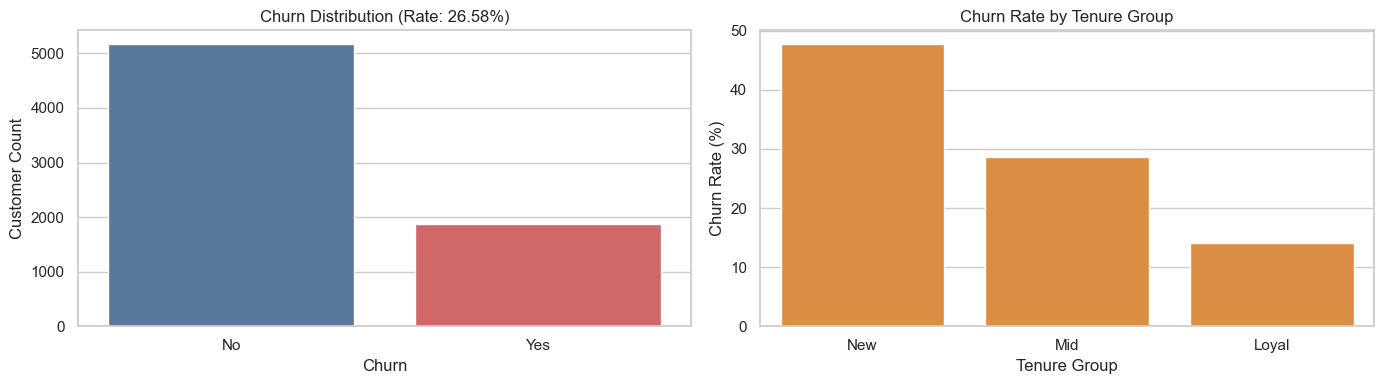

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

churn_counts = df_norm["churn"].value_counts().reindex(["No", "Yes"])
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=["#4e79a7", "#e15759"], ax=axes[0])
axes[0].set_title(f"Churn Distribution (Rate: {churn_rate:.2f}%)")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Customer Count")

tenure_churn = df_norm.groupby("tenure_group", observed=False)["churn_flag"].mean().mul(100).reset_index()
sns.barplot(data=tenure_churn, x="tenure_group", y="churn_flag", color="#f28e2b", ax=axes[1])
axes[1].set_title("Churn Rate by Tenure Group")
axes[1].set_xlabel("Tenure Group")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## Step 6: Usage, Charges, and Support Call Analysis (Visualization)
Visualize key churn drivers: usage frequency, monthly charges, and support calls.

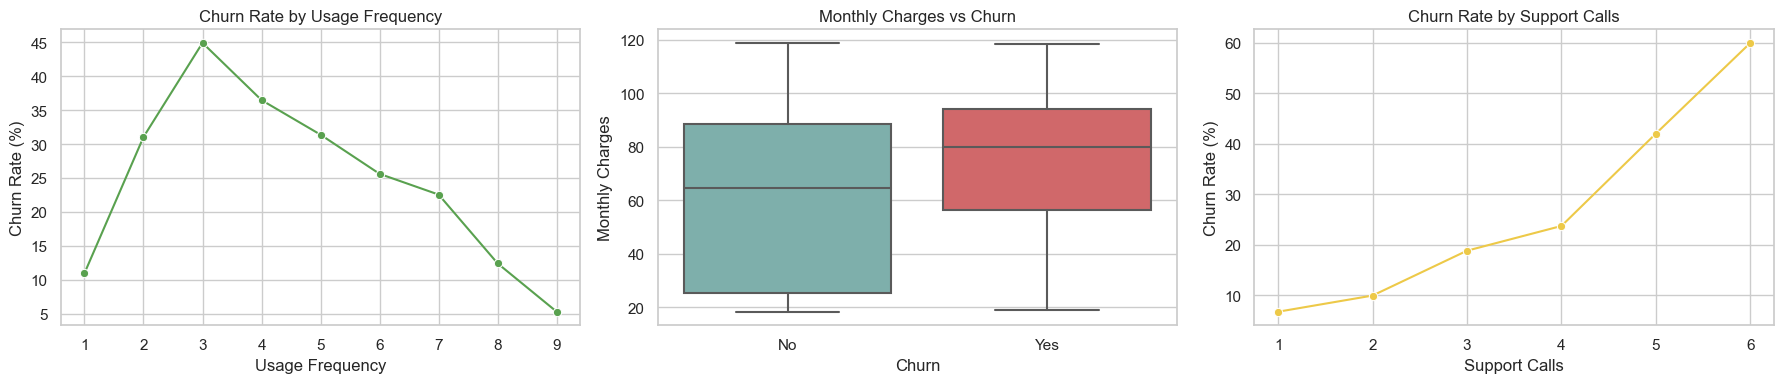

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

usage_churn = df_norm.groupby("usage_frequency")["churn_flag"].mean().mul(100)
sns.lineplot(x=usage_churn.index, y=usage_churn.values, marker="o", color="#59a14f", ax=axes[0])
axes[0].set_title("Churn Rate by Usage Frequency")
axes[0].set_xlabel("Usage Frequency")
axes[0].set_ylabel("Churn Rate (%)")

sns.boxplot(data=df_norm, x="churn", y="monthly_charges", palette=["#76b7b2", "#e15759"], ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

support_churn = df_norm.groupby("customer_support_calls")["churn_flag"].mean().mul(100)
sns.lineplot(x=support_churn.index, y=support_churn.values, marker="o", color="#edc948", ax=axes[2])
axes[2].set_title("Churn Rate by Support Calls")
axes[2].set_xlabel("Support Calls")
axes[2].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## Step 7: Correlation Analysis (Visualization)
Plot correlation heatmap for numeric features to understand directional relationships with churn.

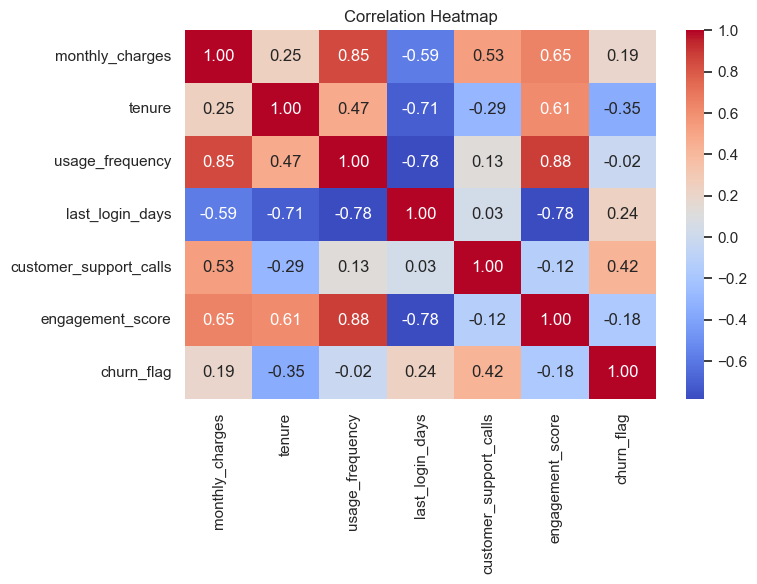

In [8]:
corr_cols = [
    "monthly_charges",
    "tenure",
    "usage_frequency",
    "last_login_days",
    "customer_support_calls",
    "engagement_score",
    "churn_flag",
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_norm[corr_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Step 8: Build Prediction Models
Train Logistic Regression and Random Forest models and compare performance metrics.

In [9]:
feature_cols = [
    "monthly_charges",
    "tenure",
    "usage_frequency",
    "last_login_days",
    "customer_support_calls",
    "subscription_plan",
    "payment_method",
]
X = df_norm[feature_cols]
y = df_norm["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["monthly_charges", "tenure", "usage_frequency", "last_login_days", "customer_support_calls"]
cat_cols = ["subscription_plan", "payment_method"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

log_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
])

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

metrics = {}
for name, model in {"Logistic Regression": log_model, "Random Forest": rf_model}.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    metrics[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob),
    }

metrics_df = pd.DataFrame(metrics).T.sort_values("roc_auc", ascending=False)
metrics_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.794598,0.633229,0.540107,0.582973,0.834117
Random Forest,0.758351,0.549133,0.508021,0.527778,0.788669


## Step 9: Model Comparison and Feature Importance (Visualization)
Visualize model accuracy and top Random Forest features.

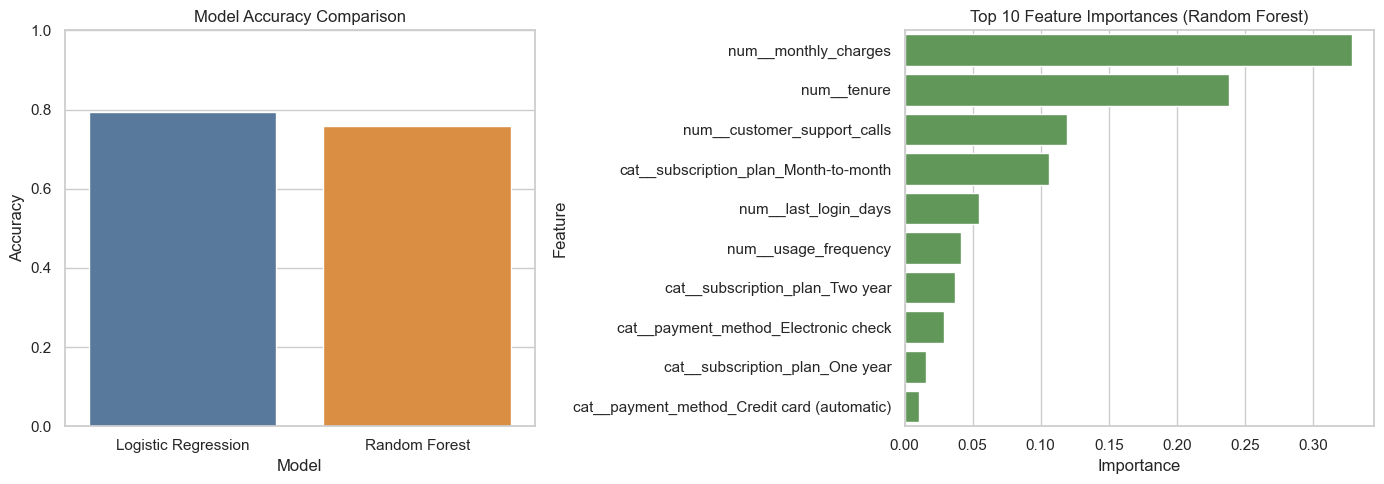

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_plot = metrics_df.reset_index().rename(columns={"index": "model"})
sns.barplot(data=acc_plot, x="model", y="accuracy", palette=["#4e79a7", "#f28e2b"], ax=axes[0])
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

feature_names = rf_model.named_steps["preprocess"].get_feature_names_out(feature_cols)
importances = rf_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(10)
sns.barplot(data=imp_df, y="feature", x="importance", color="#59a14f", ax=axes[1])
axes[1].set_title("Top 10 Feature Importances (Random Forest)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Step 10: Churn Probability and Risk Segmentation
Generate churn probabilities and classify users as Low/Medium/High risk.

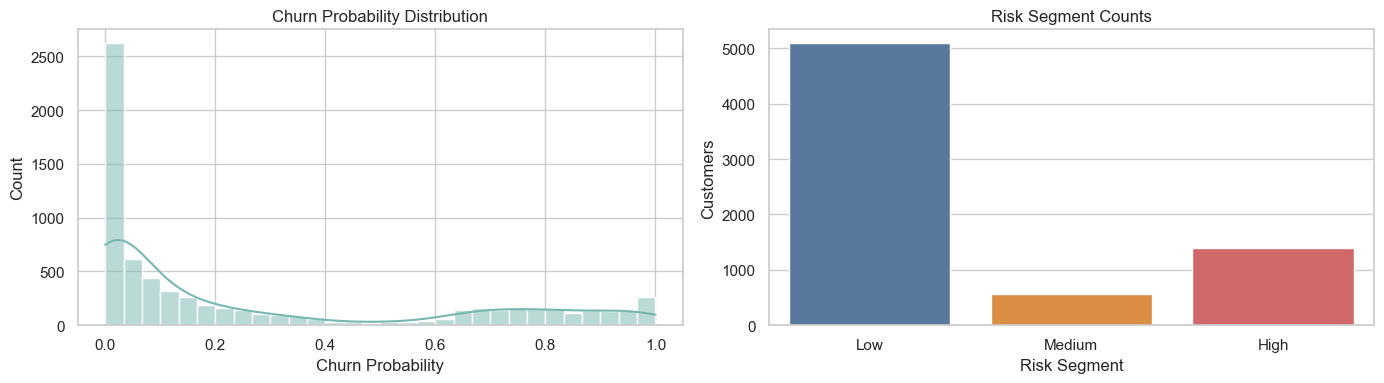

,customer_id,subscription_plan,monthly_charges,tenure,churn_probability,risk_segment,churn
1325,7206-GZCDC,Month-to-month,69.25,1,1.0,High,Yes
5872,4550-EVXNY,Month-to-month,69.65,1,1.0,High,Yes
3138,5077-DXTCG,Month-to-month,45.30,1,1.0,High,Yes
6482,5419-JPRRN,Month-to-month,101.45,1,1.0,High,Yes
6764,7660-HDPJV,Month-to-month,69.20,1,1.0,High,Yes
6488,0488-GSLFR,Month-to-month,69.50,1,1.0,High,Yes
6491,9728-FTTVZ,Month-to-month,69.20,1,1.0,High,Yes
3030,1761-AEZZR,Month-to-month,79.55,1,1.0,High,Yes
147,2135-RXIHG,Month-to-month,45.65,1,1.0,High,Yes
1650,3049-NDXFL,Month-to-month,85.80,1,1.0,High,Yes


In [11]:
df_scored = df_norm.copy()
df_scored["churn_probability"] = rf_model.predict_proba(X)[:, 1]
df_scored["risk_segment"] = pd.cut(
    df_scored["churn_probability"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_scored["churn_probability"], bins=30, kde=True, color="#76b7b2", ax=axes[0])
axes[0].set_title("Churn Probability Distribution")
axes[0].set_xlabel("Churn Probability")

risk_counts = df_scored["risk_segment"].value_counts().reindex(["Low", "Medium", "High"])
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=["#4e79a7", "#f28e2b", "#e15759"], ax=axes[1])
axes[1].set_title("Risk Segment Counts")
axes[1].set_xlabel("Risk Segment")
axes[1].set_ylabel("Customers")

plt.tight_layout()
plt.show()

df_scored.sort_values("churn_probability", ascending=False)[[
    "customer_id", "subscription_plan", "monthly_charges", "tenure", "churn_probability", "risk_segment", "churn"
]].head(10)

## Step 11: Business Recommendations
Generate practical retention actions from observed churn patterns.

In [12]:
high_risk_pct = (df_scored["risk_segment"] == "High").mean() * 100

recommendations = pd.DataFrame(
    {
        "recommendation": [
            "Offer targeted discounts to high-risk monthly-plan customers",
            "Improve onboarding for first 12 months users",
            "Run engagement campaigns for low-usage users",
            "Prioritize proactive support for high support-call users",
        ]
    }
)

print(f"High-risk users: {high_risk_pct:.2f}%")
print("\nTop model metrics:")
display(metrics_df)
print("\nRecommended actions:")
recommendations

High-risk users: 19.80%

Top model metrics:


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.794598,0.633229,0.540107,0.582973,0.834117
Random Forest,0.758351,0.549133,0.508021,0.527778,0.788669



Recommended actions:


,recommendation
0,Offer targeted discounts to high-risk monthly-...
1,Improve onboarding for first 12 months users
2,Run engagement campaigns for low-usage users
3,Prioritize proactive support for high support-...
